# Example 2 — Extract Shorkie_LM embeddings\nPull learned representations from the **first self-attention layer** (`multihead_attention`) — the layer\nused for the genomic-element t-SNE in the paper (Figure 2E). Useful for clustering / downstream tasks.\n\n**Prereqs:** same as Example 1.

In [1]:
# Resolve the released model directory via shorkie.config (works on the training
# cluster). External users: run `data/download.sh --models all` and set
# MODEL_OVERRIDE to that local dir, or edit config/paths.yaml:work_root.
import os, json, numpy as np
from shorkie import config
MODEL_OVERRIDE = os.environ.get("SHORKIE_MODELS")  # e.g. ./data_local/models
import pysam, tensorflow as tf
from baskerville import seqnn
from shorkie.models.ensemble import make_input

lm_dir = MODEL_OVERRIDE or str(config.path("models.shorkie_lm"))
fasta = pysam.Fastafile(str(config.path("genome.fasta")))
params = json.load(open(f"{lm_dir}/train/params.json")); params["model"]["num_features"] = 170
import io, contextlib
model = seqnn.SeqNN(params["model"])
with contextlib.redirect_stdout(io.StringIO()):
    model.restore(f"{lm_dir}/train/model_best.h5", trunk=False, by_name=False)
keras_model = model.model

2026-06-24 17:23:49.926639: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-24 17:23:49.968629: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-24 17:23:49.968658: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-24 17:23:49.969871: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-24 17:23:49.976849: I tensorflow/core/platform/cpu_feature_guar

2026-06-24 17:23:50.731146: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Model: "model_1"


__________________________________________________________________________________________________


 Layer (type)                Output Shape                 Param #   Connected to                  


...

Total params: 13665828 (52.13 MB)


Trainable params: 13651812 (52.08 MB)


Non-trainable params: 14016 (54.75 KB)


__________________________________________________________________________________________________


None
model_strides [1]
target_lengths [16384]
target_crops [0]


### Build an embedding model from the 1st self-attention layer

In [2]:
emb_layer = "multihead_attention"           # 1st of 8 transformer layers (multihead_attention_0..7)
emb_model = tf.keras.Model(keras_model.input, keras_model.get_layer(emb_layer).output)
print("embedding layer output shape:", emb_model.output_shape)

x = make_input(fasta, "chrI", 70000, 70000 + 16384, seq_len=16384)      # no masking
emb = emb_model(x.numpy()[None, ...], training=False).numpy()[0]         # (positions, channels)
print("embeddings for this window:", emb.shape)

embedding layer output shape: (None, 128, 384)


embeddings for this window: (128, 384)


### Quick PCA of the per-position embeddings (sanity-check structure)

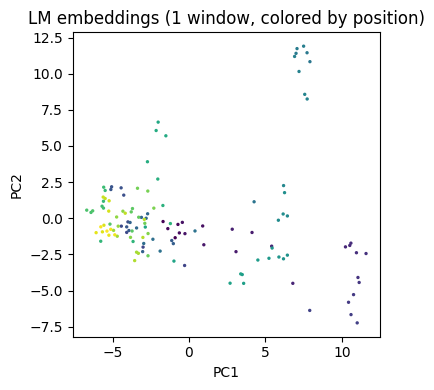

In [3]:
from sklearn.decomposition import PCA
pcs = PCA(n_components=2).fit_transform(emb)
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4)); plt.scatter(pcs[:,0], pcs[:,1], s=2, c=np.arange(len(pcs)), cmap="viridis")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("LM embeddings (1 window, colored by position)"); plt.tight_layout(); plt.show()

For the full element-level t-SNE over many windows (the paper's Figure 2E), see `reproduction/figure_02/recheck/build_2E_tsne.py` and `scripts/04_analysis/shorkie_lm/umap_cluster_promoter/`.